# 07 — Validation

Post-optimization validation of the best design:
1. Full AVL re-evaluation
2. CAD 3-view geometry
3. Alpha polar & drag breakdown
4. Propulsion balance vs speed

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
import aerosandbox as asb

from src.parameterization.design_variables import BWBParams, params_from_vector
from src.parameterization.bwb_aircraft import (
    build_airplane, compute_wing_area, compute_aspect_ratio,
)
from src.aero.evaluator import AeroEvaluator
from src.config import load_all
from src.systems.cg import compute_cg
from src.propulsion.edf_model import EDF_70MM, thrust_at_speed, endurance as compute_endurance
from src.propulsion.duct_geometry import compute_duct_placement
from src.propulsion.balance import compute_propulsion_balance
from src.visualization.style import apply_style, COLORS
from src.visualization.plots import plot_cad_multiview
apply_style()

%load_ext autoreload
%autoreload 2

# Load design + config
cfg = load_all()
mission = cfg['mission']
try:
    best_x = np.load('../output/best_x_v2.npy')
    best_params = params_from_vector(best_x)
    print('Loaded optimized design')
except FileNotFoundError:
    best_params = BWBParams()
    print('No optimized design found, using defaults')

evaluator = AeroEvaluator(
    mission=mission, feasibility=cfg['feasibility'],
    controls=cfg['controls'], cg_config=cfg['cg'],
    avl_command=cfg['avl_command'],
    aero_model=cfg['aero_model'], structure_config=cfg['structure'],
    use_cg=True,
)

Loaded optimized design


## Full AVL Re-evaluation

In [2]:
result = evaluator.evaluate(best_params)

print('=== Full AVL Evaluation (v2: real CG + elevon trim) ===\n')
print('Aerodynamics:')
for key in ['L_over_D', 'CL', 'CD', 'CD0_wing', 'CD0_body', 'CDi', 'CD_trim',
            'CM', 'CM_aero', 'CM_thrust', 'alpha_eq', 'static_margin', 'oswald_e', 'AR', 'S_ref']:
    val = result.get(key, 'N/A')
    if key == 'static_margin':
        print(f'  {key:20s} = {val:.4f} ({val*100:.1f}% MAC)')
    elif isinstance(val, float):
        print(f'  {key:20s} = {val:.5f}')

print('\nStability & Control:')
for key in ['Cn_beta', 'Cl_beta', 'elevon_deflection', 'CL_de', 'Cm_de', 'Cl_da', 'Cn_da']:
    val = result.get(key, 'N/A')
    if isinstance(val, float):
        print(f'  {key:20s} = {val:.5f}')

print('\nCG & Mass:')
print(f'  {"x_cg":20s} = {result.get("x_cg", 0)*100:.1f} cm (x/c = {result.get("x_cg_frac", 0):.3f})')
print(f'  {"struct_mass":20s} = {result["struct_mass"]*1000:.0f} g')
print(f'  {"internal_volume":20s} = {result["internal_volume"]*1e6:.0f} cm3')

print('\nPropulsion:')
for key in ['T_over_D', 'T_available', 'T_axial', 'T_normal', 'M_thrust',
            'P_elec', 'endurance_min', 'range_km', 'duct_fits']:
    val = result.get(key, 'N/A')
    if isinstance(val, float):
        if key == 'M_thrust':
            print(f'  {key:20s} = {val:.4f} N.m')
        else:
            print(f'  {key:20s} = {val:.2f}')
    else:
        print(f'  {key:20s} = {val}')

# Thrust direction check
from src.propulsion.duct_geometry import DuctSpine
dp = compute_duct_placement(best_params, mission.edf)
spine = DuctSpine(dp)
print(f'  {"nozzle_angle_phys":20s} = {spine.exhaust_angle_physical_deg():.2f}° (0° = horizontal)')

print(f'\n  {"is_feasible":20s} = {result["is_feasible"]}')
print(f'  {"penalty":20s} = {result["penalty"]:.4f}')

=== Full AVL Evaluation (v2: real CG + elevon trim) ===

Aerodynamics:
  L_over_D             = 18.83332
  CL                   = 0.04399
  CD                   = 0.01622
  CD0_wing             = 0.00400
  CD0_body             = 0.00908
  CDi                  = 0.00012
  CD_trim              = 0.00016
  CM                   = 0.00338
  CM_aero              = 0.00000
  CM_thrust            = 0.00338
  alpha_eq             = 4.50291
  static_margin        = 0.0117 (1.2% MAC)
  oswald_e             = 0.82089
  AR                   = 6.34177
  S_ref                = 0.21171

Stability & Control:
  Cn_beta              = 0.00633
  Cl_beta              = -0.04707
  elevon_deflection    = -15.91665
  CL_de                = 0.01648
  Cm_de                = -0.00451
  Cl_da                = -0.00172
  Cn_da                = 0.00007

CG & Mass:
  x_cg                 = 18.3 cm (x/c = 0.395)
  struct_mass          = 576 g
  internal_volume      = 804 cm3

Propulsion:
  T_over_D             = 2.09

## Geometry — CAD 3-View

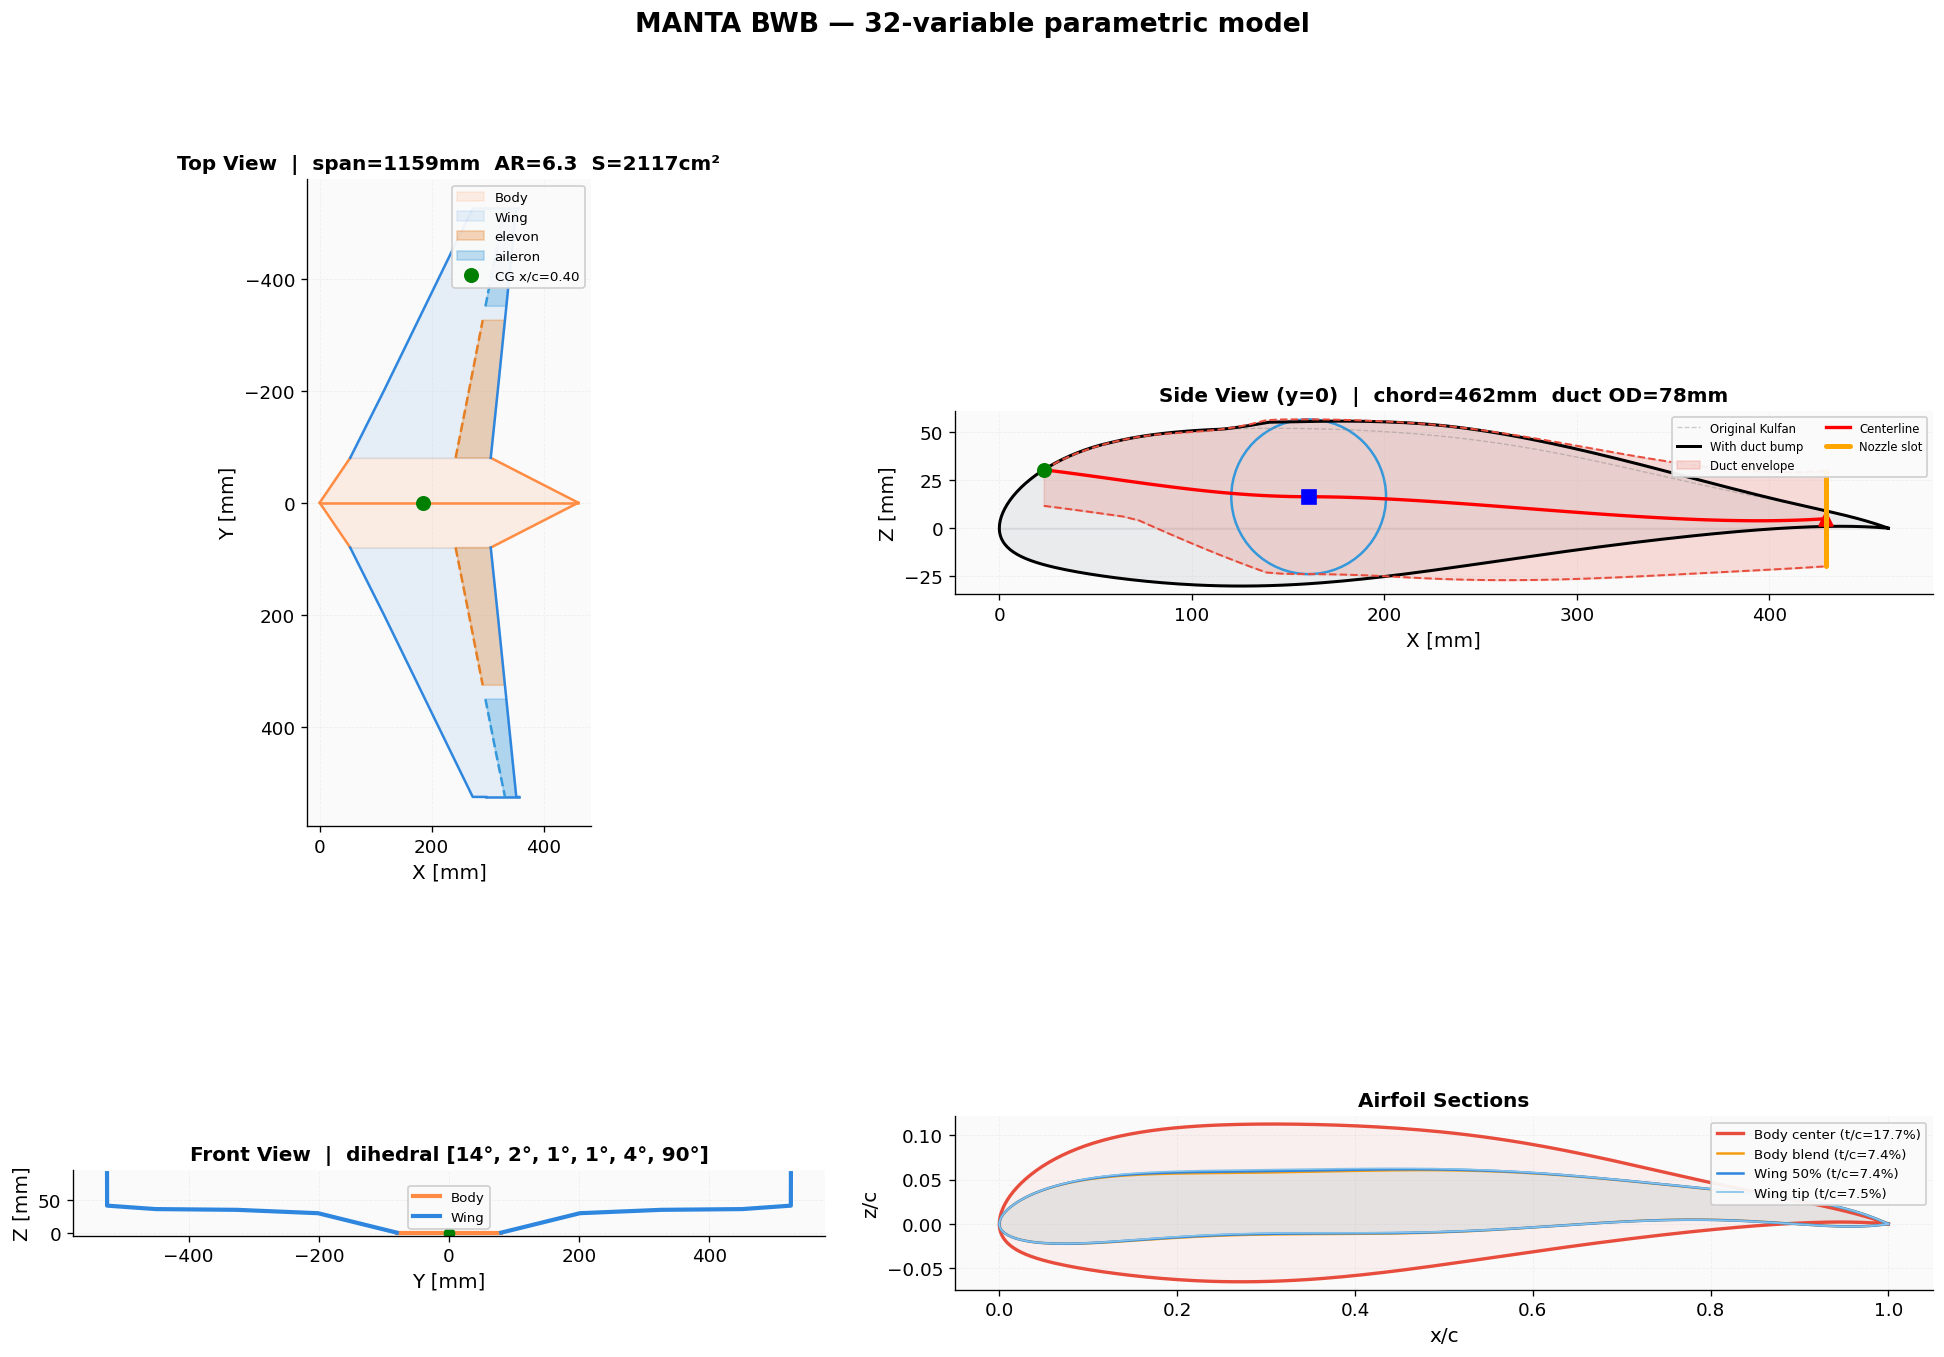

In [3]:
from src.geometry.control_surfaces import compute_control_surface_geometry

dp = compute_duct_placement(best_params, mission.edf)
geoms = compute_control_surface_geometry(best_params, cfg['controls'], n_spanwise=30)
cg_data = compute_cg(best_params, mission.battery_mass, mission.motor_mass,
                     mission.avionics_mass, cfg['cg'])

fig = plot_cad_multiview(best_params, placement=dp, controls=geoms, cg_data=cg_data)
fig.savefig('../output/v2_geometry_overview.png', dpi=150, bbox_inches='tight')
plt.show()

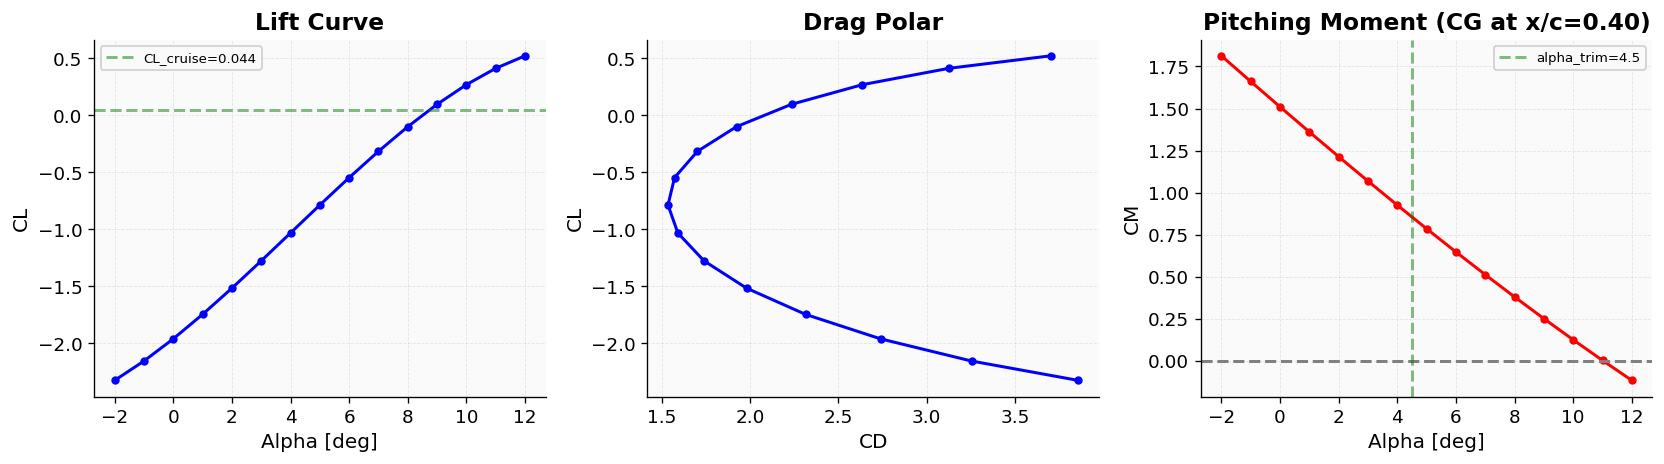

In [4]:
airplane = build_airplane(best_params, x_cg=cg_data['x_cg'])
import aerosandbox as asb

alphas = np.linspace(-2, 12, 15)
cls, cds, cms = [], [], []

for alpha in alphas:
    op = asb.OperatingPoint(
        atmosphere=mission.atmosphere,
        velocity=mission.velocity,
        alpha=alpha,
    )
    vlm = asb.VortexLatticeMethod(airplane=airplane, op_point=op,
                                   chordwise_resolution=4, spanwise_resolution=10)
    aero = vlm.run()
    cls.append(aero['CL'])
    cds.append(aero['CD'])
    cms.append(aero['Cm'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(alphas, cls, 'b-o', ms=4)
axes[0].axhline(result['CL'], color='green', ls='--', alpha=0.5, label=f'CL_cruise={result["CL"]:.3f}')
axes[0].set_xlabel('Alpha [deg]')
axes[0].set_ylabel('CL')
axes[0].set_title('Lift Curve')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cds, cls, 'b-o', ms=4)
axes[1].set_xlabel('CD')
axes[1].set_ylabel('CL')
axes[1].set_title('Drag Polar')
axes[1].grid(True, alpha=0.3)

axes[2].plot(alphas, cms, 'r-o', ms=4)
axes[2].set_xlabel('Alpha [deg]')
axes[2].set_ylabel('CM')
axes[2].set_title(f'Pitching Moment (CG at x/c={cg_data["x_cg_frac"]:.2f})')
axes[2].axhline(0, color='gray', ls='--')
axes[2].axvline(result['alpha_eq'], color='green', ls='--', alpha=0.5, label=f'alpha_trim={result["alpha_eq"]:.1f}')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Propulsion Balance vs Speed

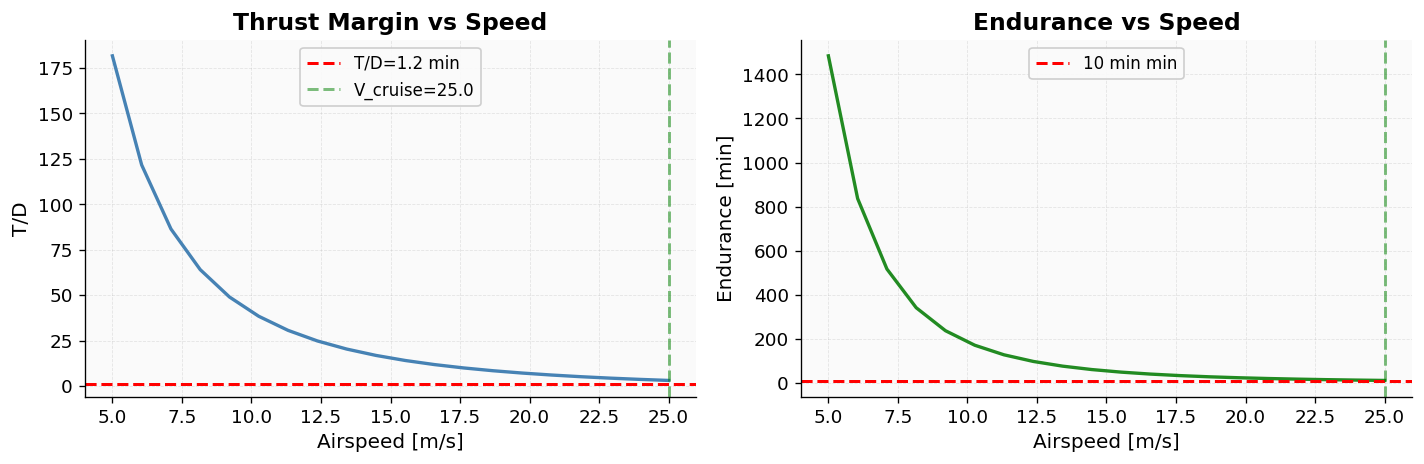

In [5]:
speeds = np.linspace(5, 25, 20)
s_ref = compute_wing_area(best_params)
td_ratios = []
endurances = []

for v in speeds:
    q = 0.5 * mission.density * v**2
    cl_req = mission.weight / (q * s_ref)
    cd_approx = result['CD']  # simplified: use same CD
    drag = cd_approx * q * s_ref
    t_avail = thrust_at_speed(EDF_70MM, v)
    td_ratios.append(t_avail / drag if drag > 0 else 0)
    e = compute_endurance(drag, v, EDF_70MM, mission.battery)
    endurances.append(e['endurance_min'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(speeds, td_ratios, 'steelblue', lw=2)
axes[0].axhline(1.2, color='red', ls='--', label='T/D=1.2 min')
axes[0].axvline(mission.velocity, color='green', ls='--', alpha=0.5, label=f'V_cruise={mission.velocity}')
axes[0].set_xlabel('Airspeed [m/s]')
axes[0].set_ylabel('T/D')
axes[0].set_title('Thrust Margin vs Speed')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(speeds, endurances, 'forestgreen', lw=2)
axes[1].axhline(10, color='red', ls='--', label='10 min min')
axes[1].axvline(mission.velocity, color='green', ls='--', alpha=0.5)
axes[1].set_xlabel('Airspeed [m/s]')
axes[1].set_ylabel('Endurance [min]')
axes[1].set_title('Endurance vs Speed')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

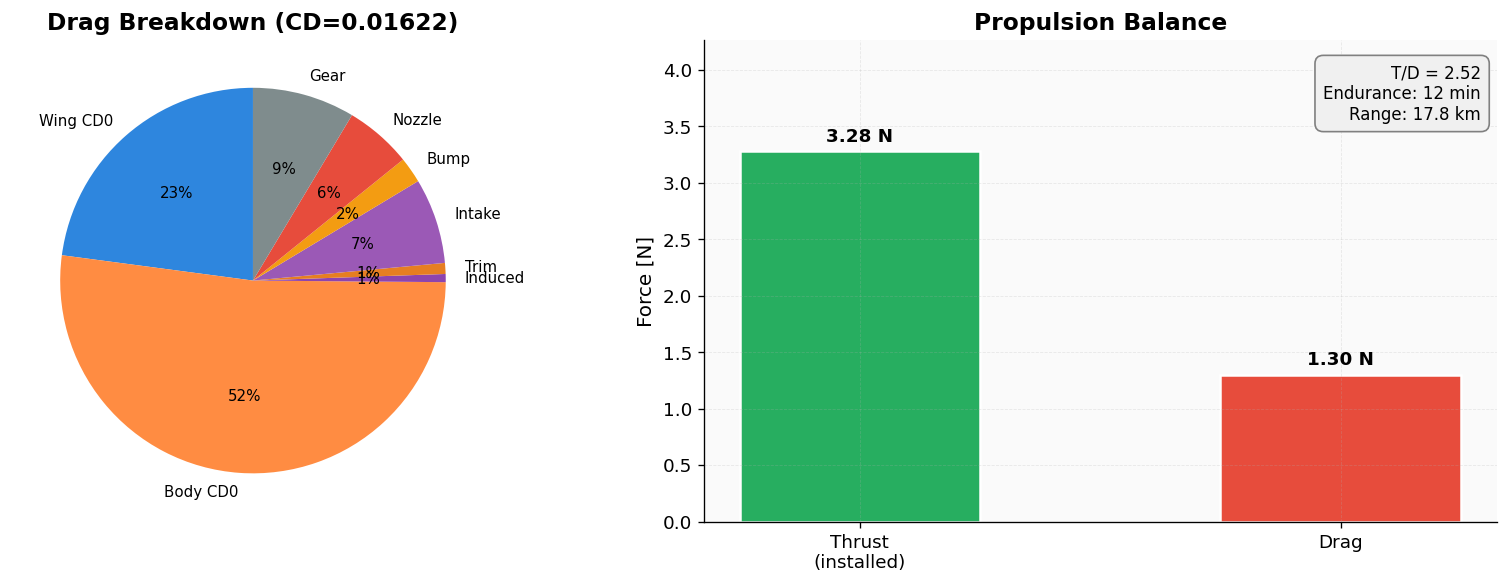

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Drag decomposition pie ---
cd_keys = ['CD0_wing', 'CD0_body', 'CDi', 'CD_trim', 'CD_intake', 'CD0_bump', 'CD_nozzle', 'CD_gear']
cd_labels = ['Wing CD0', 'Body CD0', 'Induced', 'Trim', 'Intake', 'Bump', 'Nozzle', 'Gear']
cd_colors = [COLORS['wing'], COLORS['body'], COLORS['accent'], COLORS['elevon'],
             COLORS['duct'], COLORS['warning'], COLORS['drag'], COLORS['secondary']]

vals = [result.get(k, 0) for k in cd_keys]
mask = [v > 1e-6 for v in vals]
ax1.pie([v for v, m in zip(vals, mask) if m],
        labels=[l for l, m in zip(cd_labels, mask) if m],
        colors=[c for c, m in zip(cd_colors, mask) if m],
        autopct=lambda p: f'{p:.0f}%', startangle=90, textprops={'fontsize': 9})
ax1.set_title(f'Drag Breakdown (CD={result["CD"]:.5f})', fontweight='bold')

# --- Propulsion balance bar ---
t_avail = thrust_at_speed(EDF_70MM, mission.velocity)
drag_force = result['CD'] * mission.dynamic_pressure * result['S_ref']
prop = compute_propulsion_balance(drag_force, mission.velocity, EDF_70MM, mission.battery,
                                   pr_total=result.get('pr_total', 1.0))

bars = ax2.bar(['Thrust\n(installed)', 'Drag'], [prop['T_available'], drag_force],
               color=[COLORS['thrust'], COLORS['drag']], width=0.5, edgecolor='white', lw=1.5)
for bar, val in zip(bars, [prop['T_available'], drag_force]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f} N', ha='center', va='bottom', fontsize=11, fontweight='bold')

text = f'T/D = {prop["T_over_D"]:.2f}\nEndurance: {prop["endurance_min"]:.0f} min\nRange: {prop["range_km"]:.1f} km'
ax2.text(0.98, 0.95, text, transform=ax2.transAxes, fontsize=10,
         va='top', ha='right', bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F0F0', edgecolor='gray'))
ax2.set_ylabel('Force [N]')
ax2.set_title('Propulsion Balance', fontweight='bold')
ax2.set_ylim(0, max(prop['T_available'], drag_force) * 1.3)

plt.tight_layout()
plt.savefig('../output/drag_propulsion_balance.png', dpi=150, bbox_inches='tight')
plt.show()